# Results Compilation and Figure Generation

Loads pre-computed cross-validation results from `data/model_results/` and
generates all tables and figures used in the paper.

**Inputs:**
- `data/model_results/{model}_{split}.csv`
- `data/models/VARX_9.pkl` (for correlation / trace plots)

**Outputs (all written to `images/`):**
- `images/model_comparison.pdf`
- `images/varx_interval_lengths.png`
- `images/correlation_matrices.pdf`
- `images/varx_traceplot.png`
- `images/model_calibration.png`

In [53]:
import os
import dill as pkl
from pathlib import Path

import arviz as az
import matplotlib.dates as mdates
import matplotlib.pyplot as plt
import numpy as np
import pandas as pd

import xarray as xr
import tqdm

from src.modeling.metrics import summarize

RESULTS_DIR = Path("./data/model_results")
MODEL_DIR = Path("./data/models")
IMAGES_DIR = Path("./images")
IMAGES_DIR.mkdir(exist_ok=True)

## Helpers

In [54]:
def rename_lakes(x):
    return {
        "eri": "Erie",
        "sup": "Superior",
        "mic_hur": "Michigan/Huron",
        "ont": "Ontario",
    }.get(x, x)


rename_lakes_vec = np.vectorize(rename_lakes)


def rollup_agg(df, groupings, fn=summarize):
    full_groupings = (
        df.groupby(groupings, observed=False)
        .apply(fn, include_groups=False)
        .reset_index()
    )
    all_groupings = (
        df.groupby(groupings[:-1], observed=False)
        .apply(fn, include_groups=False)
        .reset_index()
    )
    all_groupings[groupings[-1]] = "All"
    return pd.concat(
        [full_groupings, all_groupings], axis=0, ignore_index=True
    ).set_index(groupings)

## Load Data

In [55]:
lake_data = xr.open_dataarray("data/lake_data.nc")
result_files = sorted(RESULTS_DIR.glob("*.csv"))
if not result_files:
    raise FileNotFoundError(
        f"No result CSVs found in {RESULTS_DIR}. Run 02_fit_models.py first."
    )

cv_results = pd.concat(
    [pd.read_csv(f) for f in result_files], axis=0, ignore_index=True
)
cv_results["Date"] = pd.to_datetime(cv_results["Date"])
cv_results = cv_results[cv_results["months_ahead"] <= 12]
print(f"Loaded {len(result_files)} result files, {len(cv_results)} rows total")

Loaded 110 result files, 5280 rows total


## Process: Read in scaled predictions

In [56]:
scaled_predictions = cv_results[
    [
        "Date",
        "lake",
        "model",
        "mean",
        "lower",
        "upper",
        "true",
        "std",
        "months_ahead",
        "split",
    ]
]

scaled_predictions.head()

,Date,lake,model,mean,lower,upper,true,std,months_ahead,split
0,1995-03-01,sup,BoostedTrees,-0.274877,-0.854468,1.739868,-0.192712,0.648584,1,1
1,1995-04-01,sup,BoostedTrees,0.668865,-0.795006,1.739868,0.125258,0.633718,2,1
2,1995-05-01,sup,BoostedTrees,1.133382,-0.788476,1.802861,1.084880,0.647834,3,1
3,1995-06-01,sup,BoostedTrees,0.406820,-0.837830,1.802861,0.046537,0.660173,4,1
4,1995-07-01,sup,BoostedTrees,1.393449,-0.788476,1.802861,0.903050,0.647834,5,1


# Tables

## Overall Model Performance

In [57]:
MODEL_PERF_ORDER = [
    "BoostedTrees",
    "Default",
    "GP_Matern",
    "MVT",
    "MultitaskGP",
    "NARX_lag1",
    "RF",
    "SimpleLM",
    "VARX",
    "VARX_lag2",
    "VARX_lag3",
]
MODEL_PERF_LABELS = {
    "BoostedTrees": "Boosted Trees",
    "Default": "Ensemble",
    "GP_Matern": "GP (Matern-RQ)",
    "MVT": "Multivariate T",
    "MultitaskGP": "Multi-task GP",
    "NARX_lag1": "NARX",
    "RF": "Random Forest",
    "SimpleLM": "Simple LM",
    "VARX": "VARX",
    "VARX_lag2": "VARX (lag 2)",
    "VARX_lag3": "VARX (lag 3)",
}
LAKE_PERF_ORDER = ["sup", "mic_hur", "eri", "ont"]
LAKE_PERF_LABELS = {"sup": "Sup", "mic_hur": "Mic/Hur", "eri": "Eri", "ont": "Ont"}

lake_cols = LAKE_PERF_ORDER + ["All"]
model_rows = MODEL_PERF_ORDER + ["All"]

# model x lake (+ "All" lake column), from rollup_agg(["model", "lake"])
perf_by_lake = rollup_agg(scaled_predictions, ["model", "lake"])[["rmse", "coverage"]]
rmse_table = perf_by_lake["rmse"].unstack("lake")
cov_table = perf_by_lake["coverage"].unstack("lake")

# lake x model (+ "All" model row), from rollup_agg(["lake", "model"]) - gives us the "All" model row
perf_by_model = rollup_agg(scaled_predictions, ["lake", "model"])[["rmse", "coverage"]]
rmse_table.loc["All"] = perf_by_model["rmse"].xs("All", level="model")
cov_table.loc["All"] = perf_by_model["coverage"].xs("All", level="model")

# Grand total (model="All", lake="All") isn't produced by either rollup_agg call above,
# since each only collapses a single axis - so compute it directly.
grand_total = summarize(scaled_predictions)
rmse_table.loc["All", "All"] = grand_total["rmse"]
cov_table.loc["All", "All"] = grand_total["coverage"]

rmse_table = rmse_table.reindex(index=model_rows, columns=lake_cols)
cov_table = cov_table.reindex(index=model_rows, columns=lake_cols)

# Bold the best model per column (lowest RMSE, highest coverage), excluding the "All" row
rmse_bold = rmse_table.loc[MODEL_PERF_ORDER].eq(rmse_table.loc[MODEL_PERF_ORDER].min())
cov_bold = cov_table.loc[MODEL_PERF_ORDER].eq(cov_table.loc[MODEL_PERF_ORDER].max())


def fmt(value, bold):
    text = f"{value:.3f}"
    return rf"\textbf{{{text}}}" if bold else text


lake_header = " & ".join(
    r"\textit{\textbf{All}}"
    if lake == "All"
    else rf"\textbf{{{LAKE_PERF_LABELS[lake]}}}"
    for lake in lake_cols
)

lines = [
    r"\begin{table}[ht]",
    r"\centering",
    r"\caption{Model performance across lakes, measured by normalized RMSE and 95\% coverage. "
    r"Lower RMSE and higher coverage are preferred}",
    r"\label{tab:model-performance}",
    r"\small",
    r"\begin{tabular}{lrrrrrrrrrr}",
    r"\toprule",
    r" & \multicolumn{5}{c}{\textbf{RMSE}} & \multicolumn{5}{c}{\textbf{Coverage}} \\",
    r"\cmidrule(lr){2-6} \cmidrule(lr){7-11}",
    rf"\textbf{{Model}} & {lake_header} & {lake_header} \\",
    r"\midrule",
]

for model in MODEL_PERF_ORDER:
    label = MODEL_PERF_LABELS[model]
    rmse_cells = " & ".join(
        fmt(rmse_table.loc[model, lake], rmse_bold.loc[model, lake])
        for lake in lake_cols
    )
    cov_cells = " & ".join(
        fmt(cov_table.loc[model, lake], cov_bold.loc[model, lake]) for lake in lake_cols
    )
    lines.append(rf"{label} & {rmse_cells} & {cov_cells} \\")

rmse_cells = " & ".join(fmt(rmse_table.loc["All", lake], False) for lake in lake_cols)
cov_cells = " & ".join(fmt(cov_table.loc["All", lake], False) for lake in lake_cols)
lines += [
    r"\addlinespace",
    rf"All & {rmse_cells} & {cov_cells} \\",
    r"\bottomrule",
    r"\end{tabular}",
    r"\end{table}",
]

model_performance_latex = "\n".join(lines)
print(model_performance_latex)


\begin{table}[ht]
\centering
\caption{Model performance across lakes, measured by normalized RMSE and 95\% coverage. Lower RMSE and higher coverage are preferred}
\label{tab:model-performance}
\small
\begin{tabular}{lrrrrrrrrrr}
\toprule
 & \multicolumn{5}{c}{\textbf{RMSE}} & \multicolumn{5}{c}{\textbf{Coverage}} \\
\cmidrule(lr){2-6} \cmidrule(lr){7-11}
\textbf{Model} & \textbf{Sup} & \textbf{Mic/Hur} & \textbf{Eri} & \textbf{Ont} & \textit{\textbf{All}} & \textbf{Sup} & \textbf{Mic/Hur} & \textbf{Eri} & \textbf{Ont} & \textit{\textbf{All}} \\
\midrule
Boosted Trees & 0.493 & 0.479 & 0.487 & 0.483 & 0.486 & 0.833 & 0.825 & 0.867 & 0.792 & 0.829 \\
Ensemble & 0.629 & 0.703 & 0.694 & 0.697 & 0.681 & 0.875 & 0.850 & 0.875 & 0.867 & 0.867 \\
GP (Matern-RQ) & 0.431 & \textbf{0.368} & \textbf{0.470} & 0.455 & \textbf{0.433} & \textbf{0.933} & \textbf{0.967} & \textbf{0.925} & 0.917 & 0.935 \\
Multivariate T & 0.628 & 0.701 & 0.690 & 0.705 & 0.682 & 0.917 & 0.892 & \textbf{0.925} & 0.867 & 0

## Table: CRPS

In [58]:
CRPS_MODEL_ORDER = [
    "BoostedTrees",
    "Default",
    "GP_Matern",
    "MVT",
    "MultitaskGP",
    "NARX_lag1",
    "RF",
    "SimpleLM",
    "VARX",
    "VARX_lag2",
    "VARX_lag3",
]
CRPS_MODEL_LABELS = {
    "BoostedTrees": "Boosted Trees",
    "Default": "Ensemble",
    "GP_Matern": "GP (Matern-RQ)",
    "MVT": "Multivariate T",
    "MultitaskGP": "Multi-task GP",
    "NARX_lag1": "NARX",
    "RF": "Random Forest",
    "SimpleLM": "Simple LM",
    "VARX": "VARX (lag 1)",
    "VARX_lag2": "VARX (lag 2)",
    "VARX_lag3": "VARX (lag 3)",
}
CRPS_LAKE_ORDER = ["sup", "mic_hur", "eri", "ont"]
CRPS_LAKE_LABELS = {
    "sup": "Superior",
    "mic_hur": "Michigan--Huron",
    "eri": "Erie",
    "ont": "Ontario",
}
crps_lake_cols = CRPS_LAKE_ORDER + ["All"]

crps_table = rollup_agg(scaled_predictions, ["model", "lake"])["crps"].unstack("lake")
crps_table = crps_table.reindex(index=CRPS_MODEL_ORDER, columns=crps_lake_cols)


# Bold the lowest (best) CRPS per column
crps_bold = crps_table.eq(crps_table.min())

crps_lake_header = " & ".join(
    r"\textbf{All}" if lake == "All" else rf"\textbf{{{CRPS_LAKE_LABELS[lake]}}}"
    for lake in crps_lake_cols
)

crps_lines = [
    r"\begin{table}[ht]",
    r"\centering",
    r"\caption{Model performance (CRPS) across the Great Lakes. Lower values indicate better performance}",
    r"\label{tab:crps-table}",
    r"\begin{tabular}{lccccc}",
    r"\toprule",
    rf"\textbf{{Model}} & {crps_lake_header} \\",
    r"\midrule",
]

for model in CRPS_MODEL_ORDER:
    label = CRPS_MODEL_LABELS[model]
    cells = " & ".join(
        fmt(crps_table.loc[model, lake], crps_bold.loc[model, lake])
        for lake in crps_lake_cols
    )
    crps_lines.append(rf"{label} & {cells} \\")

crps_lines += [r"\bottomrule", r"\end{tabular}", r"\end{table}"]

crps_latex = "\n".join(crps_lines)
print(crps_latex)

\begin{table}[ht]
\centering
\caption{Model performance (CRPS) across the Great Lakes. Lower values indicate better performance}
\label{tab:crps-table}
\begin{tabular}{lccccc}
\toprule
\textbf{Model} & \textbf{Superior} & \textbf{Michigan--Huron} & \textbf{Erie} & \textbf{Ontario} & \textbf{All} \\
\midrule
Boosted Trees & 0.275 & 0.277 & 0.276 & 0.273 & 0.275 \\
Ensemble & 0.343 & 0.405 & 0.390 & 0.393 & 0.383 \\
GP (Matern-RQ) & 0.233 & 0.209 & \textbf{0.260} & 0.252 & \textbf{0.238} \\
Multivariate T & 0.342 & 0.399 & 0.388 & 0.396 & 0.381 \\
Multi-task GP & 0.245 & 0.217 & 0.263 & \textbf{0.246} & 0.243 \\
NARX & 0.222 & 0.206 & 0.277 & 0.256 & 0.240 \\
Random Forest & 0.296 & 0.310 & 0.290 & 0.303 & 0.300 \\
Simple LM & 0.243 & 0.211 & 0.270 & 0.282 & 0.252 \\
VARX (lag 1) & \textbf{0.221} & \textbf{0.205} & 0.277 & 0.255 & 0.240 \\
VARX (lag 2) & 0.223 & 0.207 & 0.274 & 0.255 & 0.240 \\
VARX (lag 3) & 0.226 & 0.206 & 0.274 & 0.254 & 0.240 \\
\bottomrule
\end{tabular}
\end{table}


# Figures

## RNBS Raw Values



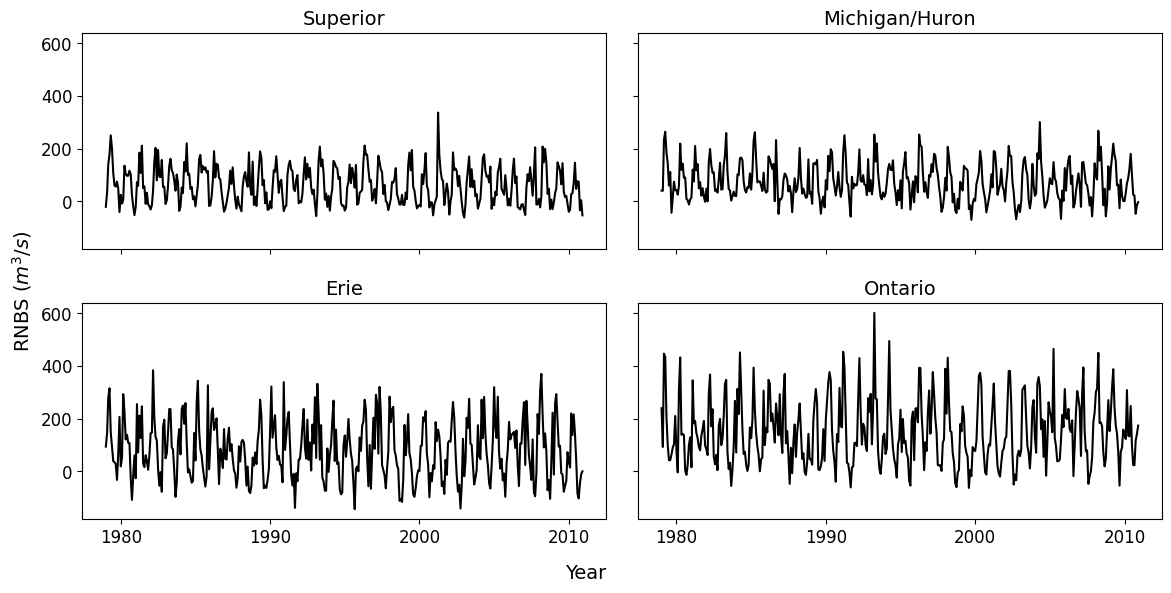

In [60]:
rnbs_raw_values = lake_data.sel(variable="rnbs").to_pandas()

fig, axs = plt.subplots(
    figsize=(12, 6),
    nrows=2,
    ncols=2,
    sharex=True,
    sharey=True,
    gridspec_kw={"hspace": 0.25, "wspace": 0.06},
)

for i, lake in enumerate(["sup", "mic_hur", "eri", "ont"]):
    ax_i = axs.flatten()[i]
    ax_i.plot(
        rnbs_raw_values.index,
        rnbs_raw_values[lake],
        color="black",
        label="Observed",
    )
    ax_i.set_title(rename_lakes(lake), fontsize=14)
    ax_i.xaxis.set_major_locator(mdates.YearLocator(10))
    ax_i.xaxis.set_major_formatter(mdates.DateFormatter("%Y"))
    ax_i.tick_params(labelsize=12)

fig.subplots_adjust(left=0.08, right=0.98, top=0.93, bottom=0.12)
fig.text(0.5, 0.02, "Year", ha="center", fontsize=14)
fig.text(0.02, 0.5, "RNBS ($m^3/s$)", va="center", rotation="vertical", fontsize=14)

plt.show()
fig.savefig(IMAGES_DIR / "rnbs_raw.pdf", dpi=300)


## Figure: Raw Covariates



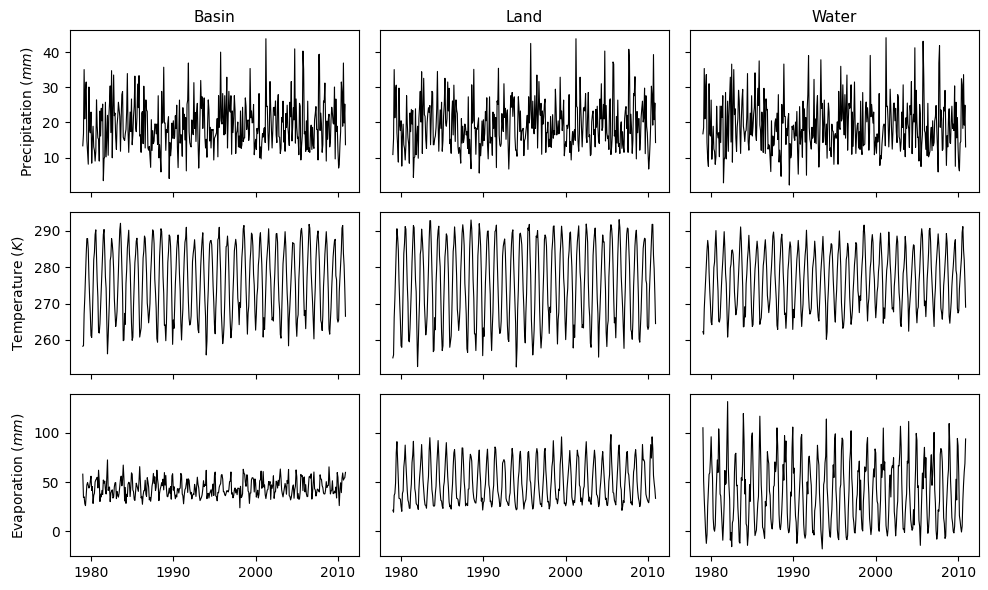

In [62]:
covar_data = (
    xr.open_dataarray("data/covar_data.nc")
    .sel(variable=["precip", "temp", "evap"], type=["Basin", "Land", "Water"])
    .dropna("Date")
    .transpose("Date", ...)
)

VARIABLE_ORDER = ["precip", "temp", "evap"]
TYPE_ORDER = ["Basin", "Land", "Water"]
VARIABLE_LABELS = {
    "precip": "Precipitation ($mm$)",
    "temp": "Temperature ($K$)",
    "evap": "Evaporation ($mm$)",
}

fig, axs = plt.subplots(
    nrows=len(VARIABLE_ORDER),
    ncols=len(TYPE_ORDER),
    figsize=(10, 6),
    sharex=True,
    sharey="row",
)

for row, variable in enumerate(VARIABLE_ORDER):
    for col, type_ in enumerate(TYPE_ORDER):
        ax = axs[row, col]
        series = covar_data.sel(variable=variable, type=type_)
        ax.plot(series["Date"], series.values, color="black", linewidth=0.8)

        if row == 0:
            ax.set_title(type_, fontsize=11)
        if col == 0:
            ax.set_ylabel(VARIABLE_LABELS[variable], fontsize=10)

        ax.xaxis.set_major_locator(mdates.YearLocator(10))
        ax.xaxis.set_major_formatter(mdates.DateFormatter("%Y"))

fig.tight_layout()
fig.savefig(IMAGES_DIR / "covars_raw.pdf")
plt.show()




## Figure: Model Forecast Comparison

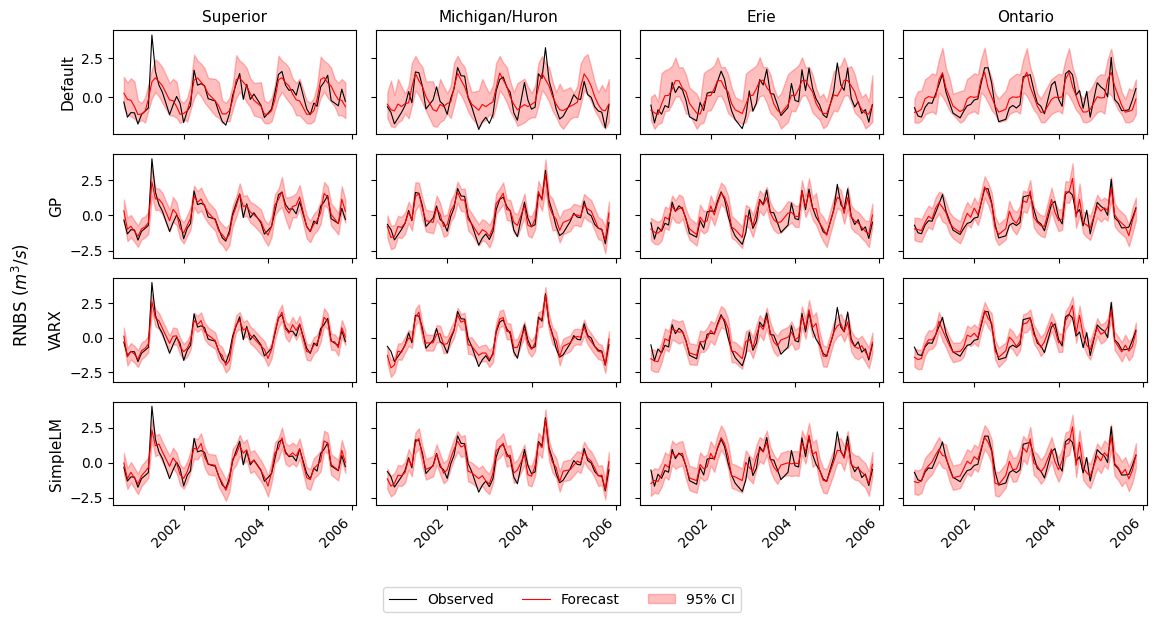

Saved images/model_comparison.pdf


In [64]:
LAKE_ORDER = ["sup", "mic_hur", "eri", "ont"]
MODEL_ORDER = ["Default", "GP_Matern", "VARX", "SimpleLM", "NARX"]
LABEL_MAP = {
    "sup": "Superior",
    "mic_hur": "Michigan/Huron",
    "eri": "Erie",
    "ont": "Ontario",
    "GP_Matern": "GP",
}


def facet_rename(x):
    return LABEL_MAP.get(x, x)


scaled_plot_data = scaled_predictions[
    (scaled_predictions["model"].isin(MODEL_ORDER)) & (scaled_predictions["split"] >= 6)
].copy()

models_present = [m for m in MODEL_ORDER if m in scaled_plot_data["model"].unique()]
lakes_present = [l for l in LAKE_ORDER if l in scaled_plot_data["lake"].unique()]

fig, axs = plt.subplots(
    len(models_present),
    len(lakes_present),
    figsize=(12, 6),
    sharex=True,
    sharey="row",
)
axs = np.atleast_2d(axs)

for row, model in enumerate(models_present):
    for col, lake in enumerate(lakes_present):
        ax = axs[row, col]
        subset = scaled_plot_data[
            (scaled_plot_data["model"] == model) & (scaled_plot_data["lake"] == lake)
        ].sort_values("Date")

        ax.plot(subset["Date"], subset["true"], color="black", lw=0.8, label="Observed")
        ax.plot(subset["Date"], subset["mean"], color="red", lw=0.8, label="Forecast")
        ax.fill_between(
            subset["Date"],
            subset["lower"],
            subset["upper"],
            color="red",
            alpha=0.25,
            label="95% CI",
        )

        if row == 0:
            ax.set_title(facet_rename(lake), fontsize=11)
        if col == 0:
            ax.set_ylabel(facet_rename(model), fontsize=11)

        ax.xaxis.set_major_locator(mdates.YearLocator(2))
        ax.xaxis.set_major_formatter(mdates.DateFormatter("%Y"))
        plt.setp(ax.get_xticklabels(), rotation=45, ha="right", fontsize=10)

fig.text(0.04, 0.5, r"RNBS $(m^3/s)$", va="center", rotation="vertical", fontsize=12)

handles, labels = axs[0, 0].get_legend_handles_labels()
fig.legend(handles, labels, loc="lower center", ncol=3, bbox_to_anchor=(0.5, -0.04))

fig.tight_layout(rect=[0.06, 0.05, 1, 1])
fig.savefig(IMAGES_DIR / "model_comparison.pdf", bbox_inches="tight")
plt.show()
print(f"Saved {IMAGES_DIR / 'model_comparison.pdf'}")

## Figure: Autoregressive Term Comparison

Reload each saved pkl, re-run `predictive_fn_` to draw from the full posterior predictive
(not just the marginal N(mean, std)), and compute per-draw RMSE.

This may take a few minutes — each call draws 500 samples for 13 forecast steps.

In [65]:
import dill
from jax import numpy as jnp
from sklearn.model_selection import TimeSeriesSplit
import jax

os.environ["JAX_PLATFORM_NAME"] = "cpu"

AR_MODELS = ["VARX", "NARX_lag1", "VARX_lag2", "VARX_lag3"]
FORECAST_STEPS = 13
LAKE_NAMES = ["sup", "mic_hur", "eri", "ont"]

# Mirror the data setup from 02_fit_models.py
lake_data = xr.open_dataarray("data/lake_data.nc")
train_data = lake_data.sel(Date=slice(None, "2005"))
X_full = train_data.sel(variable=["precip", "temp", "evap"]).drop_vars("type")
y_full = train_data.sel(variable=["rnbs"]).squeeze().drop_vars(["type", "variable"])

splitter = TimeSeriesSplit(n_splits=10, test_size=FORECAST_STEPS, gap=0)
splits = list(splitter.split(train_data))

chunks = []
for model_name in tqdm(
    AR_MODELS, desc="Predicting with AR models", unit="model", position=0
):
    # Annoying - but we're redoing the CV splits the exact same way with the initial
    # data, and then running the predictions to basically get the RMSE for each split. Normally,
    # the prediction method returns the mean and CI, but we want the individual draws this time
    # from the posterior, NOT the final average.
    for split_i, (train_id, test_id) in tqdm(
        enumerate(splits),
        desc=f"{model_name} CV splits",
        unit="split",
        position=1,
        total=10,
    ):
        pkl_path = MODEL_DIR / f"{model_name}_{split_i}.pkl"
        with open(pkl_path, "rb") as f:
            pipeline = dill.load(f)

        # model object; also includes NARX
        varx = pipeline.model.named_steps["model"]

        # Scale X through the same pipeline step that was used at fit time
        X_sub = X_full[: max(test_id) + 1]
        X_scaled = jnp.array(pipeline.model.named_steps["preprocess"].transform(X_sub))
        y_sub = (y_full[: max(test_id) + 1] - pipeline.y_mean_) / pipeline.y_std_

        months = jnp.array(y_sub.indexes["Date"].month - 1)

        # forecast_marginal: (n_samples, FORECAST_STEPS, 4_lakes)
        fm = np.array(
            varx.predictive_fn_(
                jax.random.key(split_i),
                y=jnp.array(y_sub),
                months=months,
                covariates=X_scaled,
                lags=varx.lags,
                future=FORECAST_STEPS,
            )["y_forecast"]
        )

        # True values for this split: (FORECAST_STEPS, 4_lakes)
        y_true = y_sub[test_id]

        # Squared error per (sample, months_ahead, lake): (n_samples, FORECAST_STEPS, 4)
        sq_err = (fm - y_true.values) ** 2

        n_samples = fm.shape[0]
        s_idx, t_idx, l_idx = np.meshgrid(
            np.arange(n_samples),
            np.arange(1, FORECAST_STEPS + 1),
            np.arange(4),
            indexing="ij",
        )
        chunks.append(
            pd.DataFrame(
                {
                    "model": model_name,
                    "split": split_i,
                    "months_ahead": t_idx.ravel(),
                    "lake": np.array(LAKE_NAMES)[l_idx.ravel()],
                    "rmse": np.sqrt(sq_err).ravel(),
                }
            )
        )

ar_sim_data = pd.concat(chunks, ignore_index=True)
ar_sim_data = ar_sim_data[ar_sim_data["months_ahead"] <= 12]

Predicting with AR models:   0%|          | 0/4 [00:00<?, ?model/s]

VARX CV splits:   0%|          | 0/10 [00:00<?, ?split/s]

NARX_lag1 CV splits:   0%|          | 0/10 [00:00<?, ?split/s]

VARX_lag2 CV splits:   0%|          | 0/10 [00:00<?, ?split/s]

VARX_lag3 CV splits:   0%|          | 0/10 [00:00<?, ?split/s]

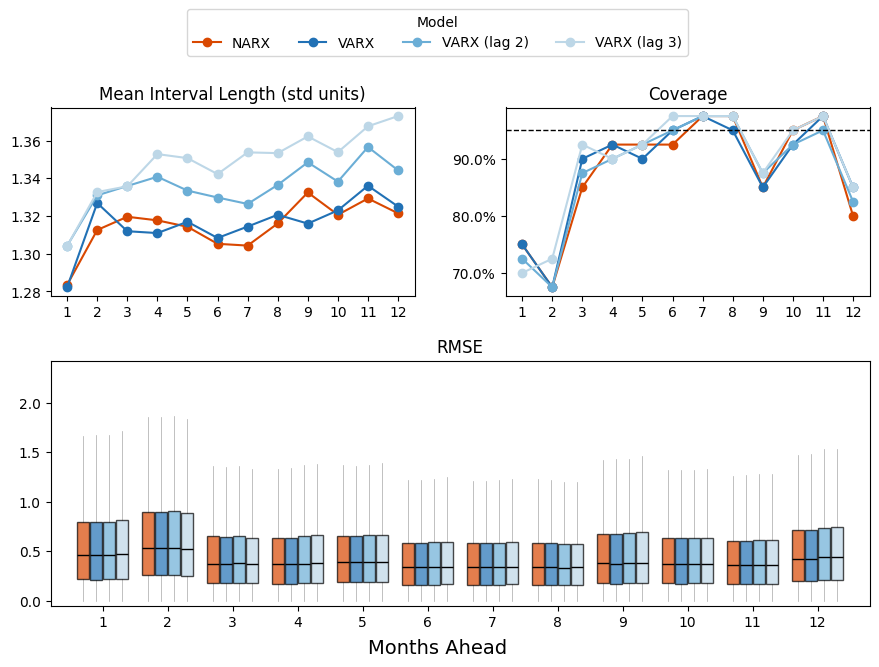

In [107]:
from matplotlib.ticker import PercentFormatter

AR_ORDER = ["NARX_lag1", "VARX", "VARX_lag2", "VARX_lag3"]
AR_LABELS = {
    "NARX_lag1": "NARX",
    "VARX": "VARX",
    "VARX_lag2": "VARX (lag 2)",
    "VARX_lag3": "VARX (lag 3)",
}
palette = {
    "NARX_lag1": "#d94801",
    "VARX": "#2171b5",
    "VARX_lag2": "#6baed6",
    "VARX_lag3": "#bdd7e7",
}

# Interval length / coverage per model x months_ahead, pooled across lakes and splits
ar_predictions = scaled_predictions[scaled_predictions["model"].isin(AR_ORDER)]
ar_summary = (
    ar_predictions.groupby(["model", "months_ahead"])
    .apply(summarize, include_groups=False)
    .reset_index()
)

months = sorted(ar_sim_data["months_ahead"].unique())
n_months = len(months)
n_models = len(AR_ORDER)
group_w = 0.8
box_w = group_w / n_models * 0.9
offsets = (np.arange(n_models) - (n_models - 1) / 2) * (group_w / n_models)

fig = plt.figure(figsize=(9, 6))
gs = fig.add_gridspec(2, 2, height_ratios=[1, 1.3], hspace=0.3, wspace=0.25)
ax_interval = fig.add_subplot(gs[0, 0])
ax_coverage = fig.add_subplot(gs[0, 1])
ax_rmse = fig.add_subplot(gs[1, :])

for model in AR_ORDER:
    color = palette[model]
    model_summary = ar_summary[ar_summary["model"] == model].sort_values("months_ahead")
    ax_interval.plot(
        model_summary["months_ahead"],
        model_summary["interval_len"],
        marker="o",
        color=color,
        label=AR_LABELS[model],
    )
    ax_coverage.plot(
        model_summary["months_ahead"],
        model_summary["coverage"],
        marker="o",
        color=color,
        label=AR_LABELS[model],
    )

ax_interval.set_title("Mean Interval Length (std units)", fontsize=12)
ax_interval.set_xticks(range(1, n_months + 1))

ax_coverage.axhline(0.95, color="black", linestyle="--", linewidth=1.0)
ax_coverage.set_title("Coverage", fontsize=12)
ax_coverage.set_xticks(range(1, n_months + 1))
ax_coverage.yaxis.set_major_formatter(PercentFormatter(xmax=1.0))

for m_idx, model in enumerate(AR_ORDER):
    color = palette[model]
    model_subset = ar_sim_data[ar_sim_data["model"] == model]
    positions = [t + offsets[m_idx] for t in range(1, n_months + 1)]
    data_arrays = [
        model_subset[model_subset["months_ahead"] == m]["rmse"].values for m in months
    ]
    ax_rmse.boxplot(
        data_arrays,
        positions=positions,
        widths=box_w,
        patch_artist=True,
        showfliers=False,
        showcaps=False,
        whis=1.5,
        boxprops=dict(facecolor=color, alpha=0.7, linewidth=1.0),
        whiskerprops=dict(color="black", linewidth=0.5, alpha=0.35),
        medianprops=dict(color="black"),
    )

ax_rmse.set_title("RMSE", fontsize=12)
ax_rmse.set_xticks(range(1, n_months + 1))
ax_rmse.set_xticklabels(months)
ax_rmse.set_ylim(-0.05, np.percentile(ar_sim_data["rmse"], 99.95))

handles, labels = ax_interval.get_legend_handles_labels()
fig.legend(
    handles,
    labels,
    title="Model",
    loc="upper center",
    ncol=len(AR_ORDER),
    bbox_to_anchor=(0.5, 1.075),
)

fig.subplots_adjust(
    left=0.07, right=0.98, top=0.90, bottom=0.07, hspace=0.3, wspace=0.25
)
fig.text(0.5, 0.00, "Months Ahead", ha="center", va="center", fontsize=14)
fig.savefig(str(IMAGES_DIR / "varx_interval_lengths.pdf"), bbox_inches="tight", dpi=300)
plt.show()

## Figure: VARX Posterior Correlation Matrix

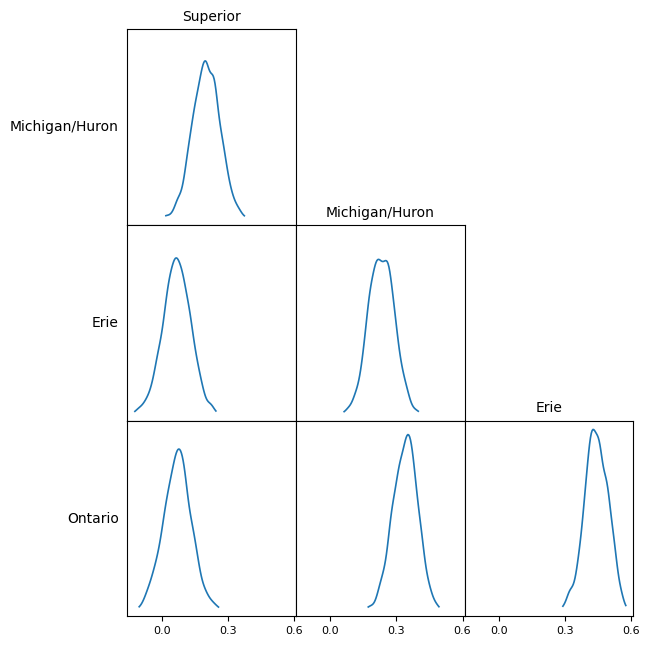

Saved images/correlation_matrices.pdf


In [70]:
from scipy.stats import gaussian_kde
import dill

valid_set = [
    ("mic_hur", "sup"),
    ("eri", "sup"),
    ("eri", "mic_hur"),
    ("ont", "sup"),
    ("ont", "mic_hur"),
    ("ont", "eri"),
]

fig, axs = plt.subplots(nrows=4, ncols=4, figsize=(9, 9), sharex=True, sharey=True)
axs = axs.flatten()

triangle_plots = [4, 8, 9, 12, 13, 14]
valid_pairs = valid_set.copy()

with open(MODEL_DIR / "VARX_lag2_9.pkl", "rb") as f:
    pipeline = dill.load(f)

varx = pipeline.model.named_steps["model"]
trace = varx.trace_

# fix this - missing proper variable names; use the order from 02_fit_models.py (hacky, but can't be skipped!)
coord_order = ["precip", "temp", "evap"]
trace.posterior.coords["variable"] = coord_order


for idx in range(16):
    ax = axs[idx]

    if idx not in triangle_plots:
        ax.set_visible(False)
        continue

    series, lake = valid_pairs.pop(0)
    subtrace = trace.posterior["corr"].sel(series=series, lakes=lake)

    data = subtrace.values.flatten()
    kde = gaussian_kde(data)

    lo, hi = -0.1, 0.8  # np.percentile(data, [0.5, 99.5])
    pad = (hi - lo) * 0.15
    xs = np.linspace(lo - pad, hi + pad, 300)
    ys = kde(xs)

    mask = ys > ys.max() * 0.02
    ax.plot(xs[mask], ys[mask], linewidth=1.2)
    # ax.set_xlim(xs[mask][0], xs[mask][-1])

    ax.set_yticks([])
    ax.set_ylabel("")
    ax.set_xlabel("")

    row = idx // 4
    col = idx % 4

    if row == 3:
        ax.xaxis.set_major_locator(plt.MaxNLocator(3))
        ax.tick_params(axis="x", labelsize=8)
    else:
        ax.set_xticks([])

    if row == col + 1:
        ax.set_title(rename_lakes(lake), fontsize=10, pad=6)

    if col == 0:
        ax.annotate(
            rename_lakes(series),
            xy=(0, 0.5),
            xycoords="axes fraction",
            ha="right",
            va="center",
            fontsize=10,
            xytext=(-6, 0),
            textcoords="offset points",
        )

plt.subplots_adjust(
    wspace=0.0, hspace=0.0, left=0.20, right=0.95, top=0.95, bottom=0.08
)
plt.savefig(str(IMAGES_DIR / "correlation_matrices.pdf"), bbox_inches="tight")
plt.show()
print(f"Saved {IMAGES_DIR / 'correlation_matrices.pdf'}")


## Figure: VARX Trace Plot

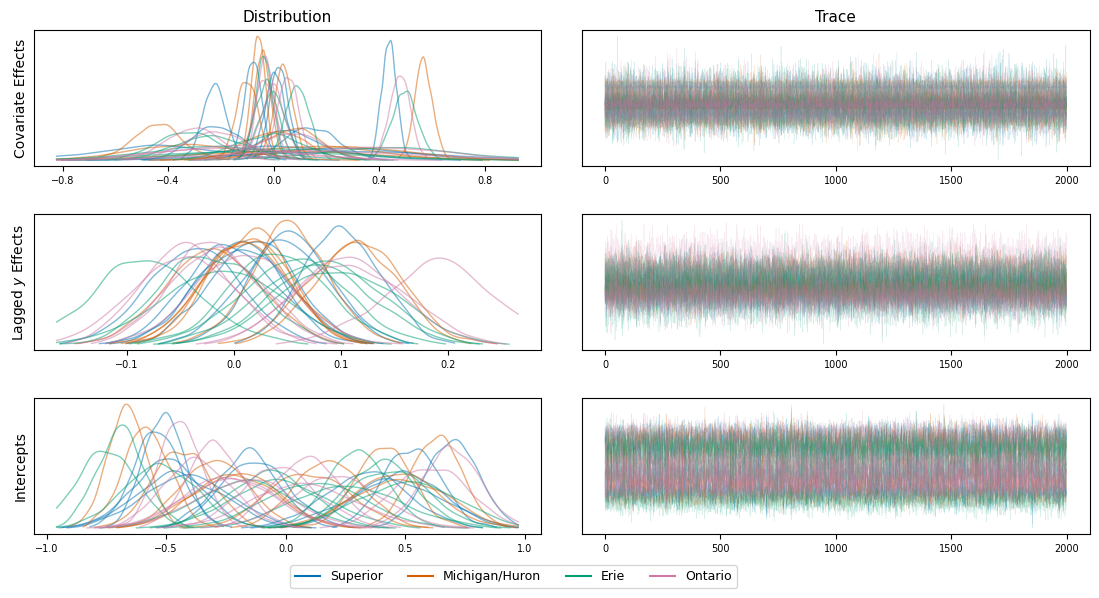

In [83]:
from scipy.stats import gaussian_kde

lake_colors = {
    "sup": "#0072B2",  # blue
    "mic_hur": "#D55E00",  # vermillion
    "eri": "#009E73",  # bluish green
    "ont": "#CC79A7",  # reddish purple
}

covar_alphas = trace.posterior[
    "covar_alphas"
]  # (chain, draw, covariate, series, lakes)
y_alphas = trace.posterior["y_alphas"]  # (chain, draw, lag, series, lakes)
intercept = trace.posterior["intercept"]  # (chain, draw, month, lakes)

fig, axs = plt.subplots(
    nrows=3,
    ncols=2,
    figsize=(12, 6),
    gridspec_kw={"wspace": 0.08, "hspace": 0.35, "width_ratios": [1, 1]},
)


def plot_row(ax_kde, ax_trace, values_by_lake, row_label):
    all_vals = np.concatenate([v for vals in values_by_lake.values() for v in vals])
    lo, hi = np.percentile(all_vals, [0.5, 99.5])
    pad = (hi - lo) * 0.05
    xs = np.linspace(lo - pad, hi + pad, 400)

    for lake in LAKE_NAMES:
        color = lake_colors[lake]
        for data in values_by_lake[lake]:
            ys = gaussian_kde(data)(xs)
            mask = ys > ys.max() * 0.02
            ax_kde.plot(xs[mask], ys[mask], color=color, linewidth=1.0, alpha=0.5)
            ax_trace.plot(data, color=color, linewidth=0.4, alpha=0.15)

    ax_kde.set_yticks([])
    ax_kde.set_ylabel(row_label, fontsize=10)
    ax_kde.xaxis.set_major_locator(plt.MaxNLocator(5))
    ax_kde.tick_params(axis="x", labelsize=7)
    ax_trace.set_yticks([])
    ax_trace.xaxis.set_major_locator(plt.MaxNLocator(5))
    ax_trace.tick_params(axis="x", labelsize=7)


# Row 1: covariate effects - color by source lake, pooled across covariates and target lakes
covar_values = {
    source_lake: [
        covar_alphas.sel(covariate=cov, series=source_lake, lakes=target_lake)
        .stack(samples=("chain", "draw"))
        .values
        for cov in covar_alphas.covariate.values
        for target_lake in LAKE_NAMES
    ]
    for source_lake in LAKE_NAMES
}
plot_row(axs[0, 0], axs[0, 1], covar_values, "Covariate Effects")

# Row 2: lagged y effects - color by source lake, pooled across lags and target lakes
y_alpha_values = {
    source_lake: [
        y_alphas.sel(lag=lag, series=source_lake, lakes=target_lake)
        .stack(samples=("chain", "draw"))
        .values
        for lag in y_alphas.lag.values
        for target_lake in LAKE_NAMES
    ]
    for source_lake in LAKE_NAMES
}
plot_row(axs[1, 0], axs[1, 1], y_alpha_values, "Lagged $y$ Effects")

# Row 3: intercepts - color by lake, pooled across months
intercept_values = {
    lake: [
        intercept.sel(lakes=lake, month=month).stack(samples=("chain", "draw")).values
        for month in intercept.month.values
    ]
    for lake in LAKE_NAMES
}
plot_row(axs[2, 0], axs[2, 1], intercept_values, "Intercepts")

axs[0, 0].set_title("Distribution", fontsize=11)
axs[0, 1].set_title("Trace", fontsize=11)

lake_handles = [
    plt.Line2D([0], [0], color=lake_colors[l], linewidth=1.5, label=rename_lakes(l))
    for l in LAKE_NAMES
]
fig.legend(
    handles=lake_handles,
    loc="lower center",
    ncol=len(LAKE_NAMES),
    bbox_to_anchor=(0.5, 0.0),
    fontsize=9,
)

fig.subplots_adjust(
    left=0.1, right=0.98, top=0.94, bottom=0.1, hspace=0.35, wspace=0.08
)
fig.savefig(str(IMAGES_DIR / "varx_traceplot.pdf"), bbox_inches="tight", dpi=300)
plt.show()

# Interval calibration curves

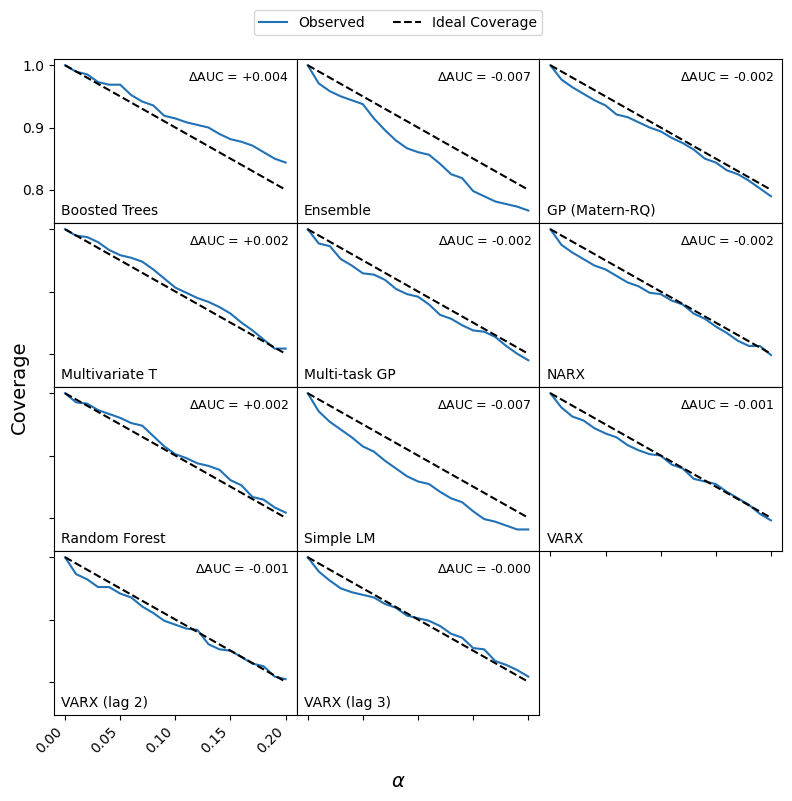

In [ ]:
from scipy.stats import norm

ALPHAS = np.linspace(0, 0.20, 21)
N_COLS = 3

fig, axs = plt.subplots(nrows=4, ncols=N_COLS, figsize=(8, 8), sharex=True, sharey=True)
axs = axs.flatten()

# Bottom-most filled panel index per column (needed since the grid isn't fully filled)
bottom_idx_per_col = {}
for idx in range(len(MODEL_PERF_ORDER)):
    bottom_idx_per_col[idx % N_COLS] = idx
bottom_left_idx = bottom_idx_per_col[0]

min_coverage = 1.0
for idx, model in enumerate(MODEL_PERF_ORDER):
    ax = axs[idx]
    subset = scaled_predictions[scaled_predictions["model"] == model]

    observed_coverage = []
    for alpha in ALPHAS:
        z = norm.ppf(1 - alpha / 2)
        lower = subset["mean"] - z * subset["std"]
        upper = subset["mean"] + z * subset["std"]
        observed_coverage.append(
            ((subset["true"] >= lower) & (subset["true"] <= upper)).mean()
        )
    observed_coverage = np.array(observed_coverage)
    min_coverage = min(min_coverage, observed_coverage.min())

    # Signed area between the observed and ideal coverage curves: negative means the
    # model is overconfident (undercovers) on average across alpha, positive means
    # conservative (overcovers).
    auc_diff = np.trapezoid(observed_coverage - (1 - ALPHAS), ALPHAS)

    ax.plot(ALPHAS, observed_coverage, color="#2171b5", label="Observed")
    ax.plot(ALPHAS, 1 - ALPHAS, color="black", linestyle="--", label="Ideal Coverage")
    ax.text(0.03, 0.05, MODEL_PERF_LABELS[model], transform=ax.transAxes, fontsize=10)
    ax.text(
        0.97,
        0.93,
        rf"$\Delta$AUC = {auc_diff:+.3f}",
        transform=ax.transAxes,
        fontsize=9,
        ha="right",
        va="top",
    )

    # Every left-column/bottom-most panel keeps tick marks (for scale reference), but
    # only the very first panel (top-left) shows y-axis numbers, and only the
    # bottom-left panel shows x-axis numbers - the rest is implied by the shared scale.
    col = idx % N_COLS
    is_left = col == 0
    is_bottom = idx == bottom_idx_per_col[col]
    ax.tick_params(
        top=False,
        right=False,
        left=is_left,
        labelleft=(idx == 0),
        bottom=is_bottom,
        labelbottom=(idx == bottom_left_idx),
    )
    plt.setp(ax.get_xticklabels(), rotation=45, ha="right")

fig.delaxes(axs[-1])

axs[0].set_ylim(min_coverage - 0.02, 1.01)

handles, labels = axs[0].get_legend_handles_labels()
fig.legend(handles, labels, loc="upper center", ncol=2, bbox_to_anchor=(0.5, 1.0))

fig.subplots_adjust(
    left=0.07, right=0.98, top=0.93, bottom=0.11, hspace=0.0, wspace=0.0
)
fig.text(0.5, 0.02, r"$\alpha$", ha="center", fontsize=14)
fig.text(0.015, 0.52, "Coverage", va="center", rotation="vertical", fontsize=14)

fig.savefig(str(IMAGES_DIR / "model_calibration.pdf"), bbox_inches="tight", dpi=200)
plt.show()